In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Data/stud.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

In [5]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [8]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [9]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
## Exploring Dataset

print("Categories in 'gender' variable : ", end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable : ", end=" ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental level of education' variable : ", end=" ")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable : ", end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable : ", end=" ")
print(df['test_preparation_course'].unique())

Categories in 'gender' variable :  <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' variable :  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' variable :  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable :  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable :  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [17]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'str']
cat_features = [feature for feature in df.columns if df[feature].dtype == 'str']

print(f'We have {len(numeric_features)} numerical features : {numeric_features}')
print(f'We have {len(cat_features)} categorical features : {cat_features}')

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [18]:
## Adding columns for 'Total Score' and 'Average'
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score'] / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [23]:
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100]['average'].count()

print(f"Number of students with full marks in reading : {reading_full}")
print(f"Number of students with full marks in writing : {writing_full}")
print(f"Number of students with full marks in math : {math_full}")

Number of students with full marks in reading : 17
Number of students with full marks in writing : 14
Number of students with full marks in math : 7


In [24]:
reading_full = df[df['reading_score'] <= 20]['average'].count()
writing_full = df[df['writing_score'] <= 20]['average'].count()
math_full = df[df['math_score'] <= 20]['average'].count()

print(f"Number of students with less than 20 marks in reading : {reading_full}")
print(f"Number of students with less than 20 marks in writing : {writing_full}")
print(f"Number of students with less than 20 marks in math : {math_full}")

Number of students with less than 20 marks in reading : 1
Number of students with less than 20 marks in writing : 3
Number of students with less than 20 marks in math : 4


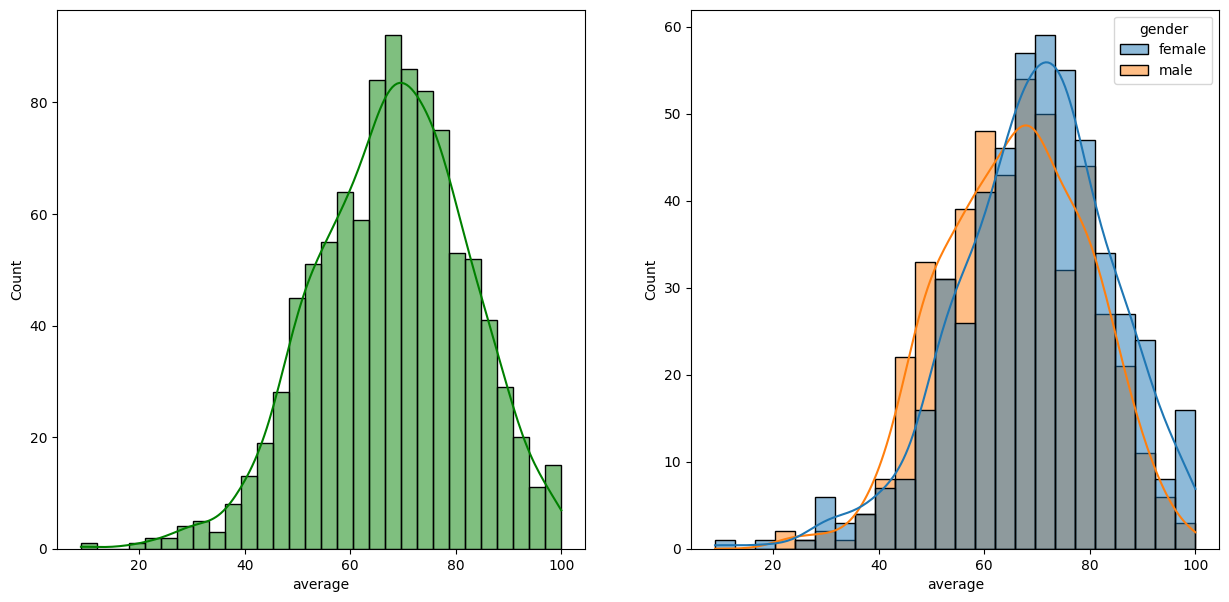

In [33]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='average', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='average', kde=True, hue='gender')
plt.show()

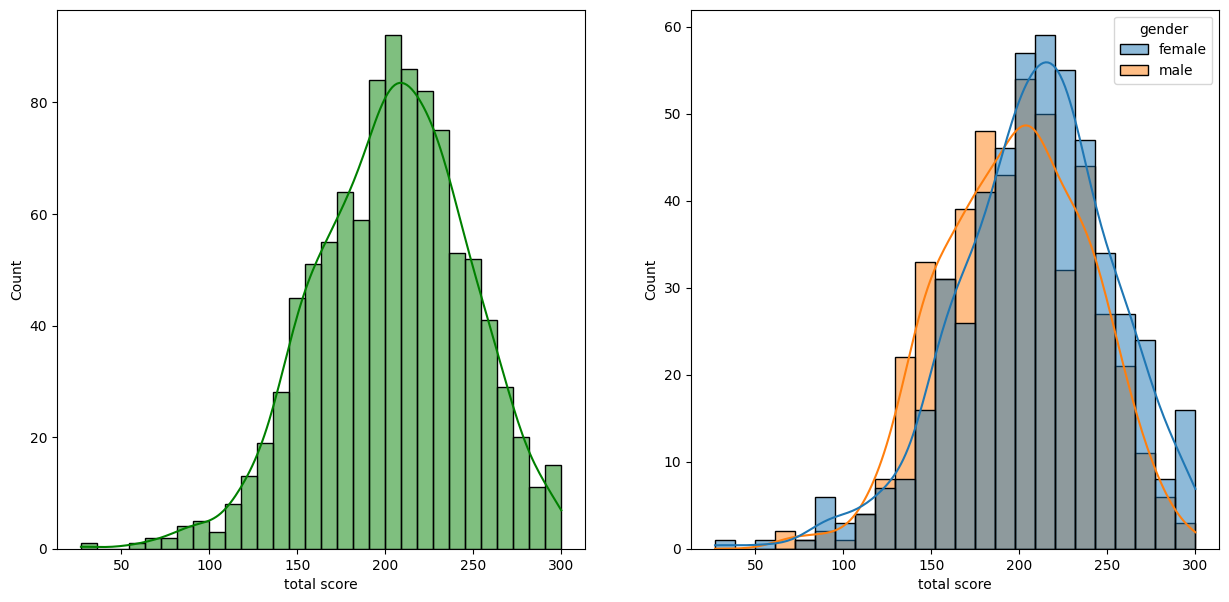

In [41]:
plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='total score', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='total score', kde=True, hue='gender')
plt.show()

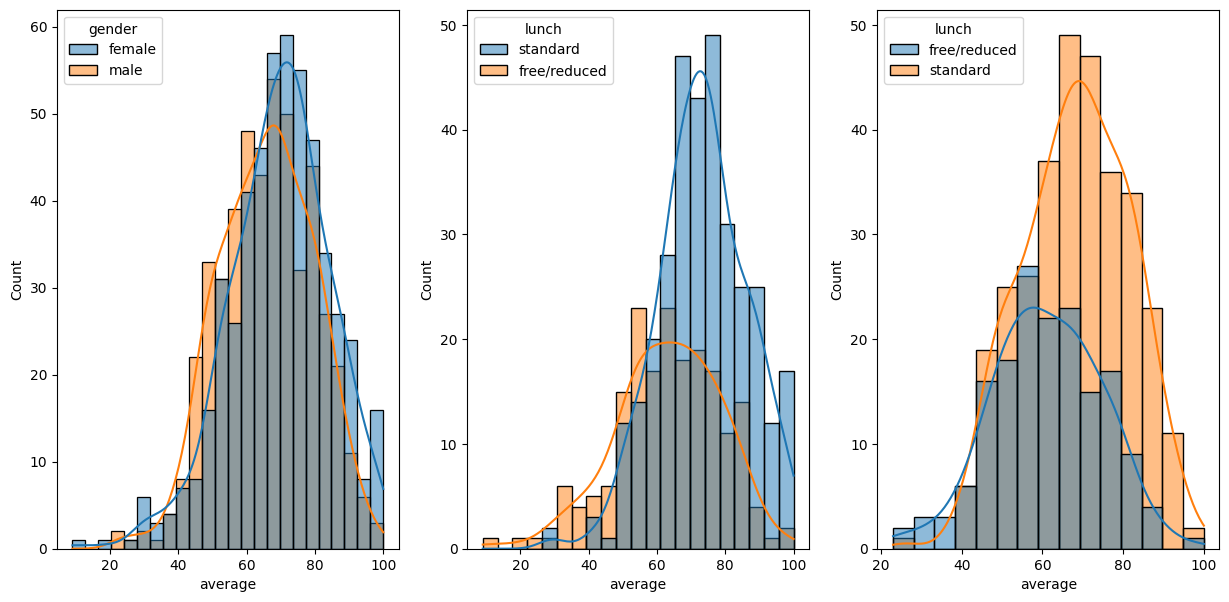

In [ ]:
plt.subplots(1,3,figsize=(15,7))
plt.subplot(131)
sns.histplot(data=df, x='average', kde=True, hue='gender')
plt.subplot(132)
sns.histplot(data=df[df['gender'] == 'female'], x='average', kde=True, hue='lunch')
plt.subplot(133)
sns.histplot(data=df[df['gender'] == 'male'], x='average', kde=True, hue='lunch')
plt.show()

In [46]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


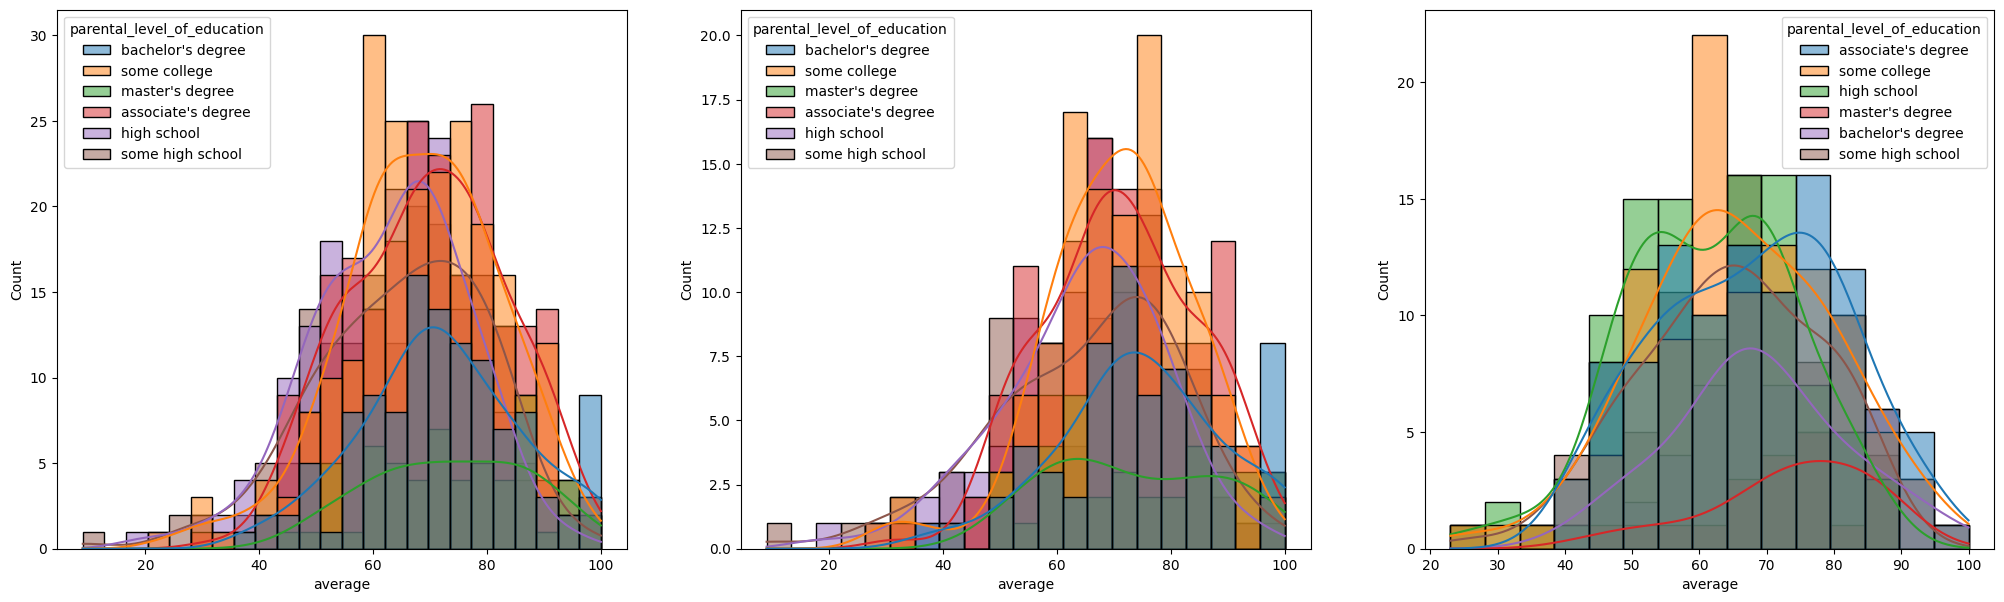

In [48]:
plt.subplots(1,3,figsize=(25,7))
plt.subplot(131)
sns.histplot(data=df, x='average', kde=True, hue='parental_level_of_education')
plt.subplot(132)
sns.histplot(data=df[df['gender'] == 'female'], x='average', kde=True, hue='parental_level_of_education')
plt.subplot(133)
sns.histplot(data=df[df['gender'] == 'male'], x='average', kde=True, hue='parental_level_of_education')
plt.show()

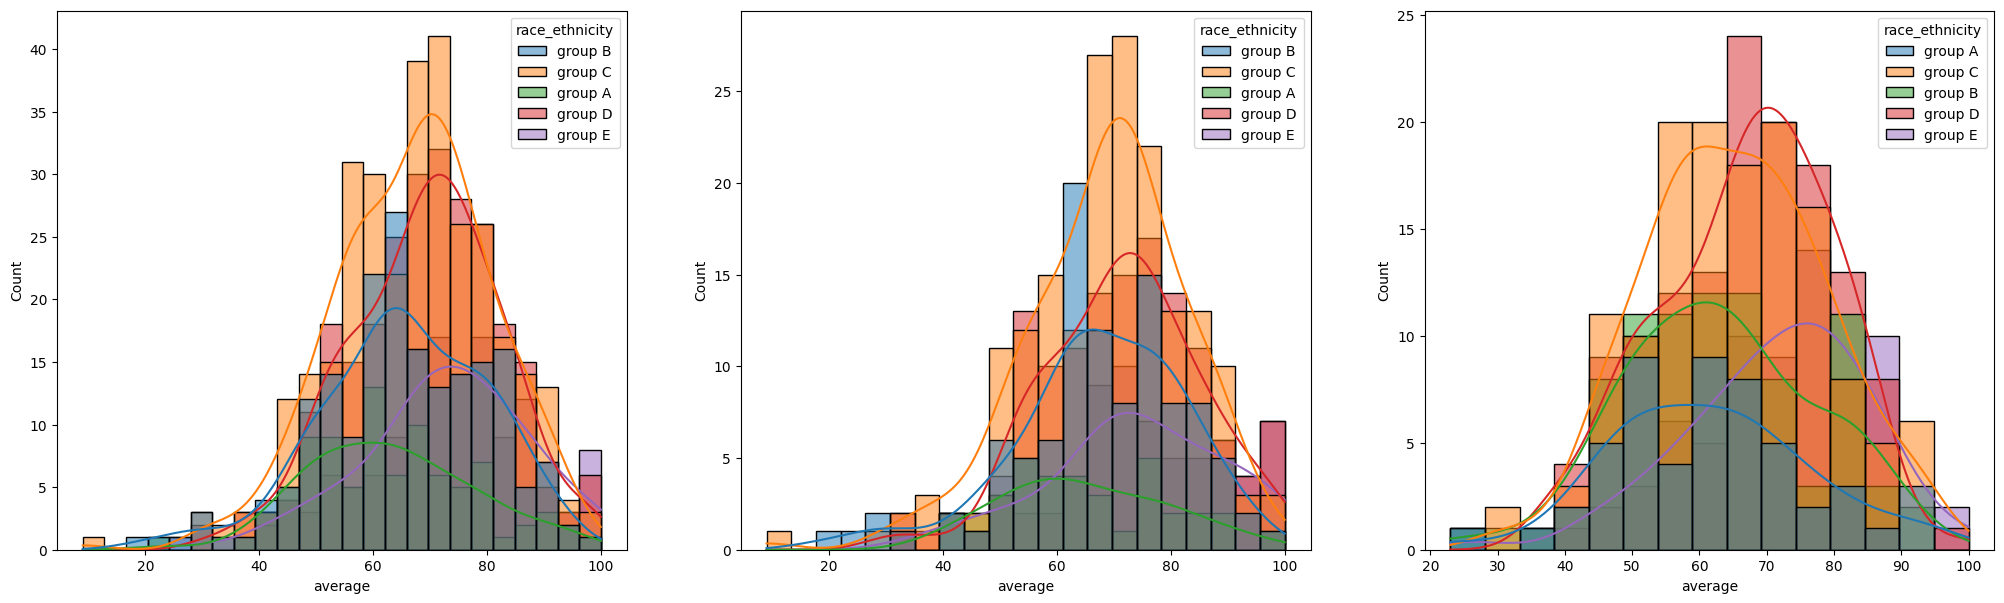

In [49]:
plt.subplots(1,3,figsize=(25,7))
plt.subplot(131)
sns.histplot(data=df, x='average', kde=True, hue='race_ethnicity')
plt.subplot(132)
sns.histplot(data=df[df['gender'] == 'female'], x='average', kde=True, hue='race_ethnicity')
plt.subplot(133)
sns.histplot(data=df[df['gender'] == 'male'], x='average', kde=True, hue='race_ethnicity')
plt.show()

<Axes: title={'center': 'Writing Scores'}, ylabel='writing_score'>

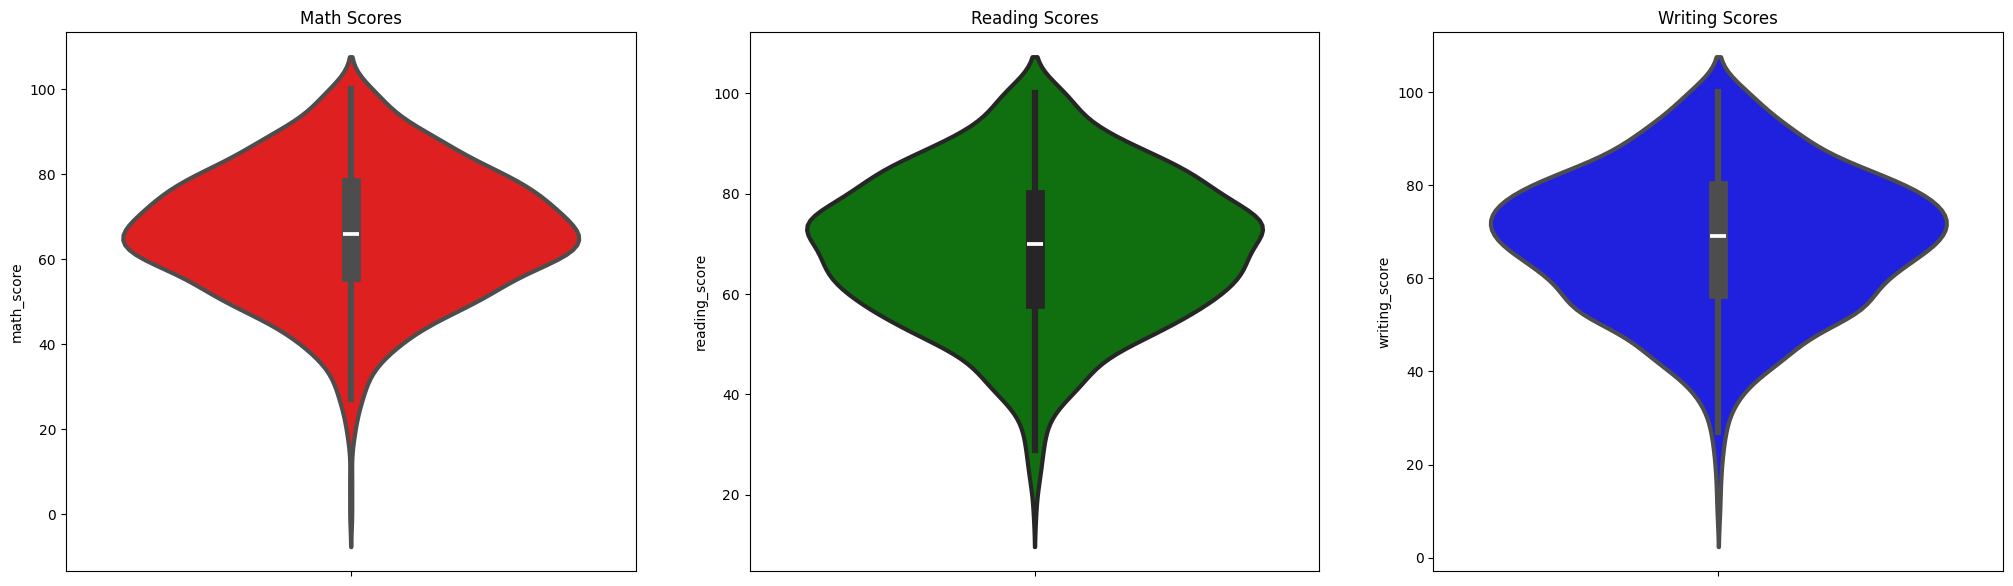

In [50]:
plt.subplots(1,3,figsize=(25,7))
plt.subplot(131)
plt.title('Math Scores')
sns.violinplot(data=df, y='math_score', color='red', linewidth=3)
plt.subplot(132)
plt.title('Reading Scores')
sns.violinplot(data=df, y='reading_score', color='green', linewidth=3)
plt.subplot(133)
plt.title('Writing Scores')
sns.violinplot(data=df, y='writing_score', color='blue', linewidth=3)

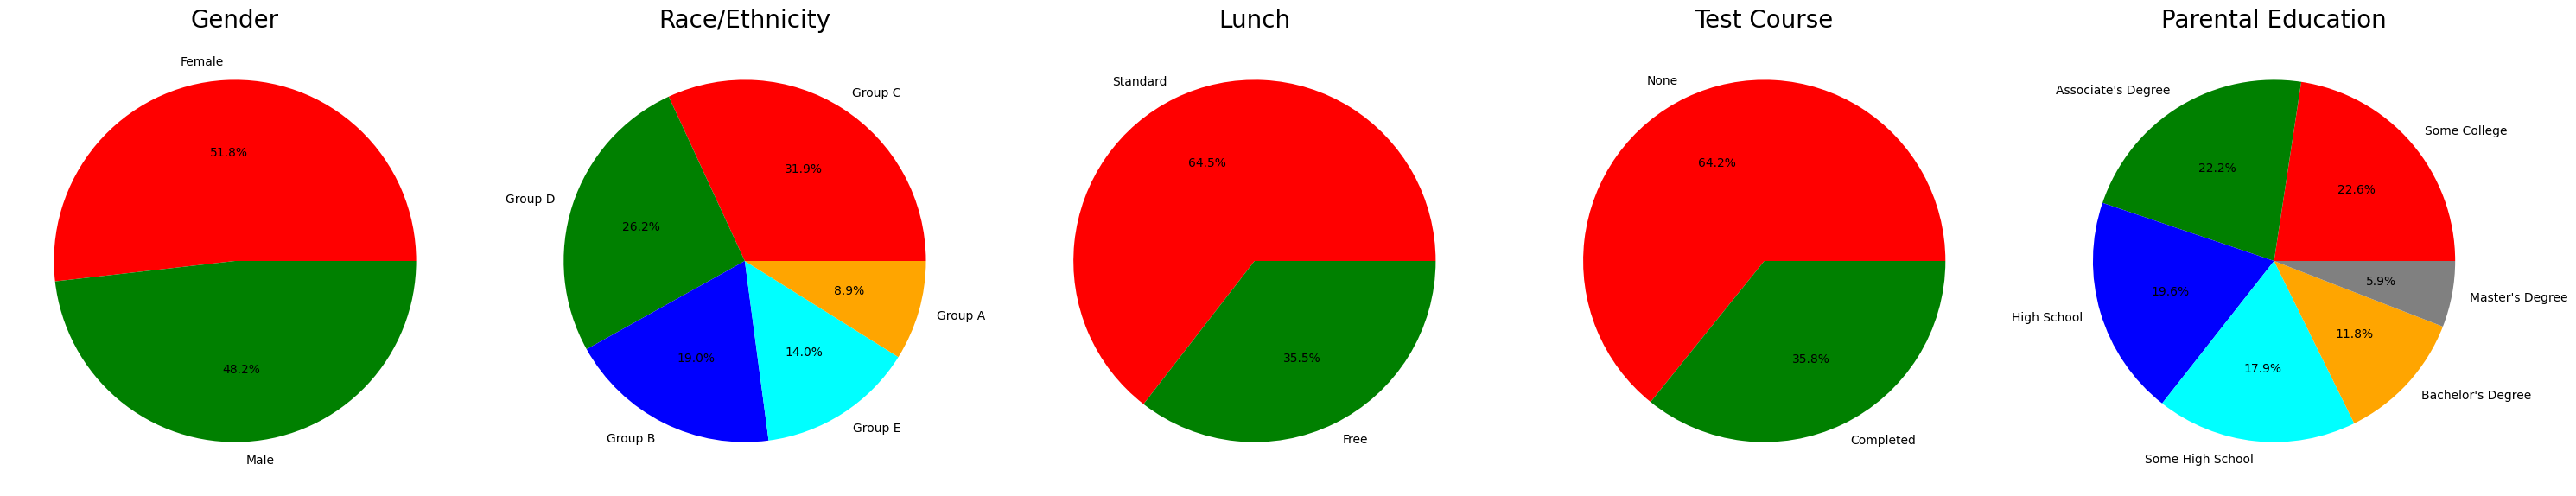

In [64]:
plt.rcParams['figure.figsize'] = (30,12)

plt.subplot(151)
size = df['gender'].value_counts()
labels = 'Female','Male'
color = ['red','green']
plt.pie(size, colors=color, labels=labels, autopct='%1.1f%%')
plt.title('Gender', fontsize=20)
plt.axis('off')

plt.subplot(152)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']
plt.pie(size, colors = color,labels = labels,autopct = '%1.1f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']
plt.pie(size, colors = color,labels = labels,autopct = '%1.1f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']
plt.pie(size, colors = color,labels = labels,autopct = '%1.1f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']
plt.pie(size, colors = color,labels = labels,autopct = '%1.1f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

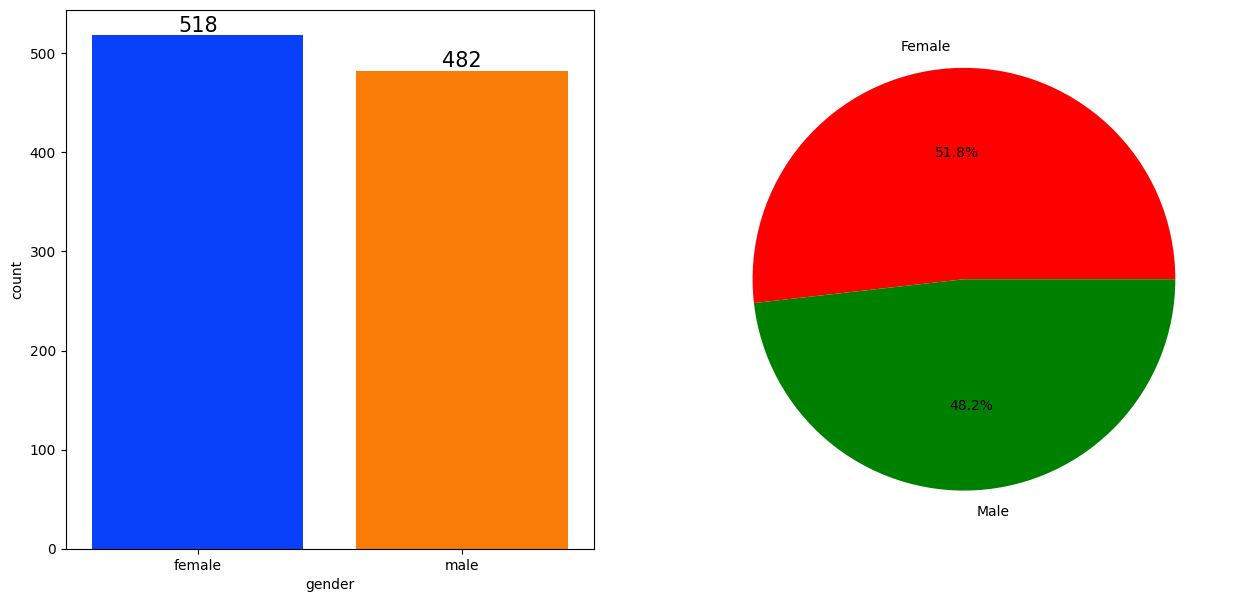

In [67]:
f,ax = plt.subplots(1,2,figsize = (15,7))
sns.countplot(x=df['gender'], data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)

plt.pie(x=df['gender'].value_counts(), colors=['red','green'], labels=['Female','Male'], autopct='%1.1f%%')
plt.show()

In [73]:
gender_grp = df.groupby('gender').mean(numeric_only=True)
gender_grp

,math_score,reading_score,writing_score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


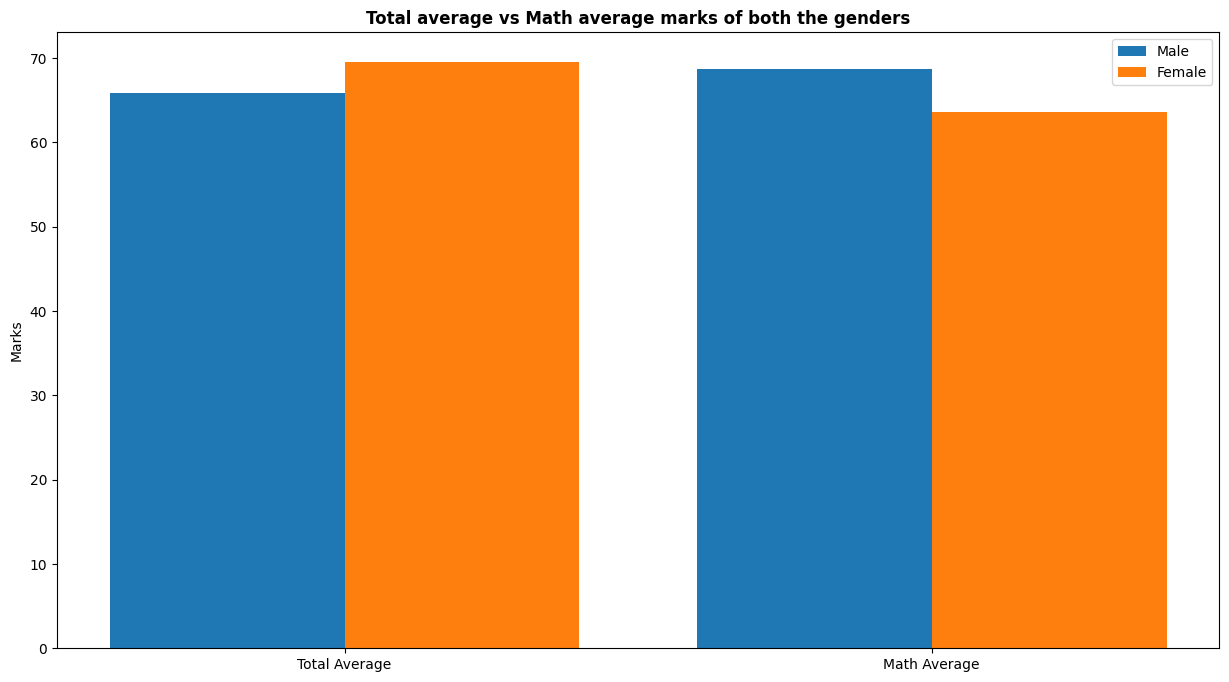

In [75]:
plt.figure(figsize=(15,8))

x = ['Total Average', 'Math Average']

female_scores = [gender_grp['average']['female'], gender_grp['math_score']['female']]
male_scores = [gender_grp['average']['male'], gender_grp['math_score']['male']]

x_axis = np.arange(len(x))

plt.bar(x_axis-0.2, male_scores, 0.4, label='Male')
plt.bar(x_axis+0.2, female_scores, 0.4, label='Female')

plt.xticks(x_axis,x)
plt.ylabel('Marks')
plt.title('Total average vs Math average marks of both the genders', fontweight='bold')
plt.legend()
plt.show()

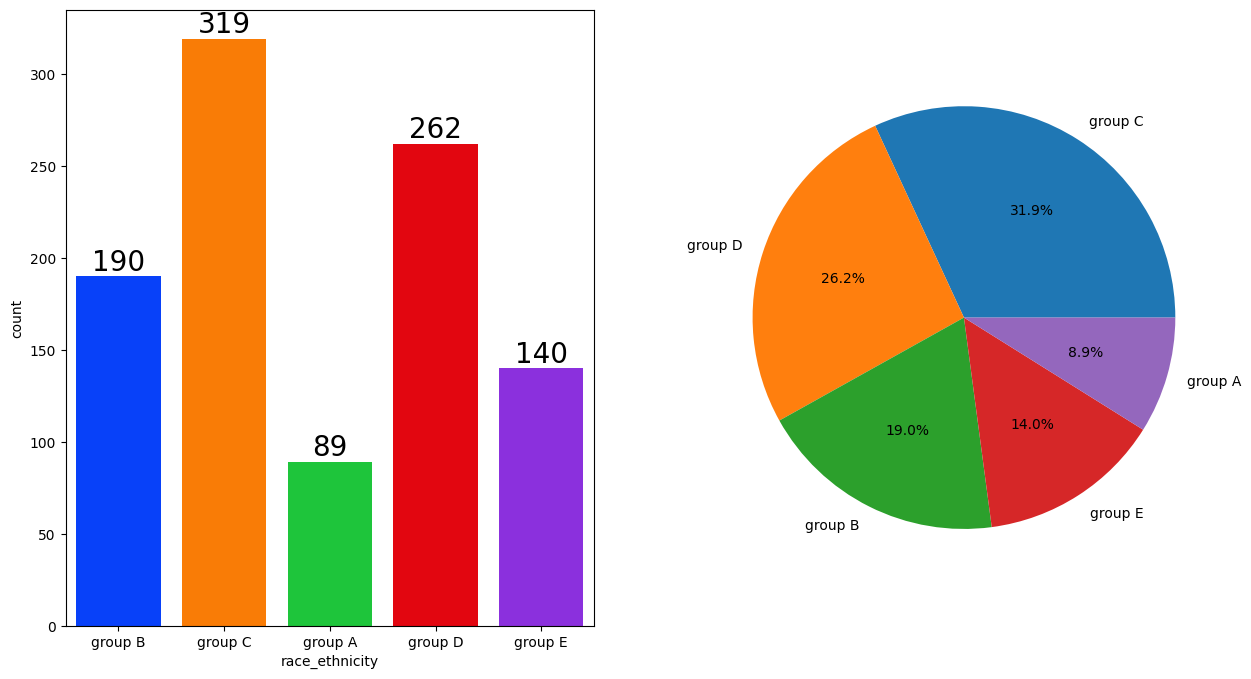

In [79]:
f,ax = plt.subplots(1,2,figsize=(15,8))
sns.countplot(x=df['race_ethnicity'], data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

plt.pie(x=df['race_ethnicity'].value_counts(), labels=df['race_ethnicity'].value_counts().index, autopct='%1.1f%%')
plt.show()

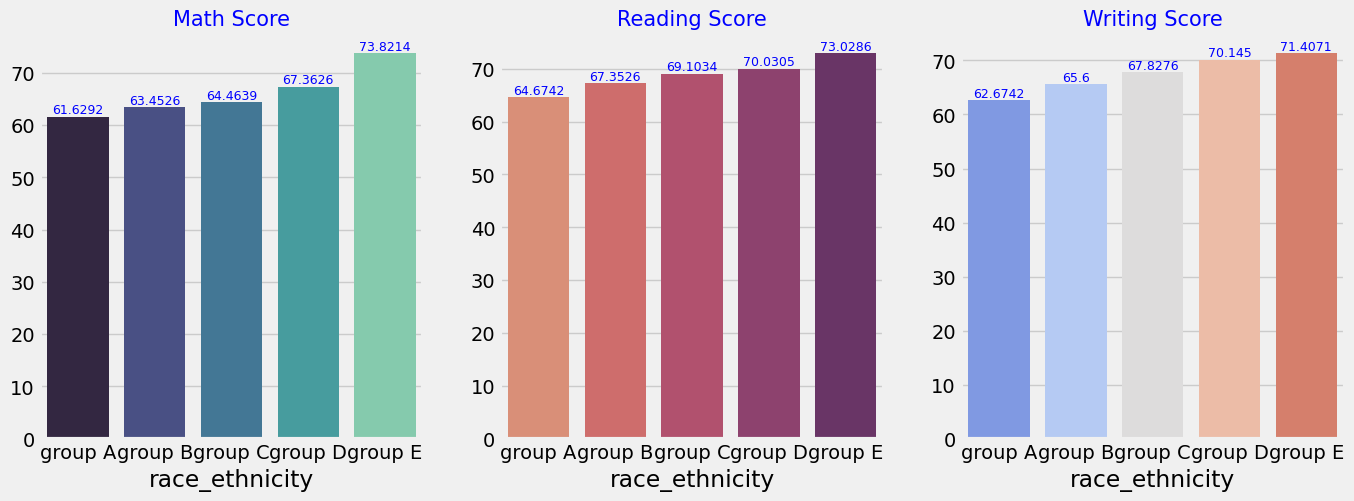

In [88]:
grp_data = df.groupby('race_ethnicity')
f,ax = plt.subplots(1,3,figsize=(15,5))
sns.barplot(x=grp_data['math_score'].mean().index, y=grp_data['math_score'].mean().values, palette='mako', ax=ax[0])
ax[0].set_title('Math Score', color='blue', size=15)
for container in ax[0].containers:
    ax[0].bar_label(container, color='blue', size=9)

sns.barplot(x=grp_data['reading_score'].mean().index, y=grp_data['reading_score'].mean().values, palette='flare', ax=ax[1])
ax[1].set_title('Reading Score', color='blue', size=15)
for container in ax[1].containers:
    ax[1].bar_label(container, color='blue', size=9)
    
sns.barplot(x=grp_data['writing_score'].mean().index, y=grp_data['writing_score'].mean().values, palette='coolwarm', ax=ax[2])
ax[2].set_title('Writing Score', color='blue', size=15)
for container in ax[2].containers:
    ax[2].bar_label(container, color='blue', size=9)

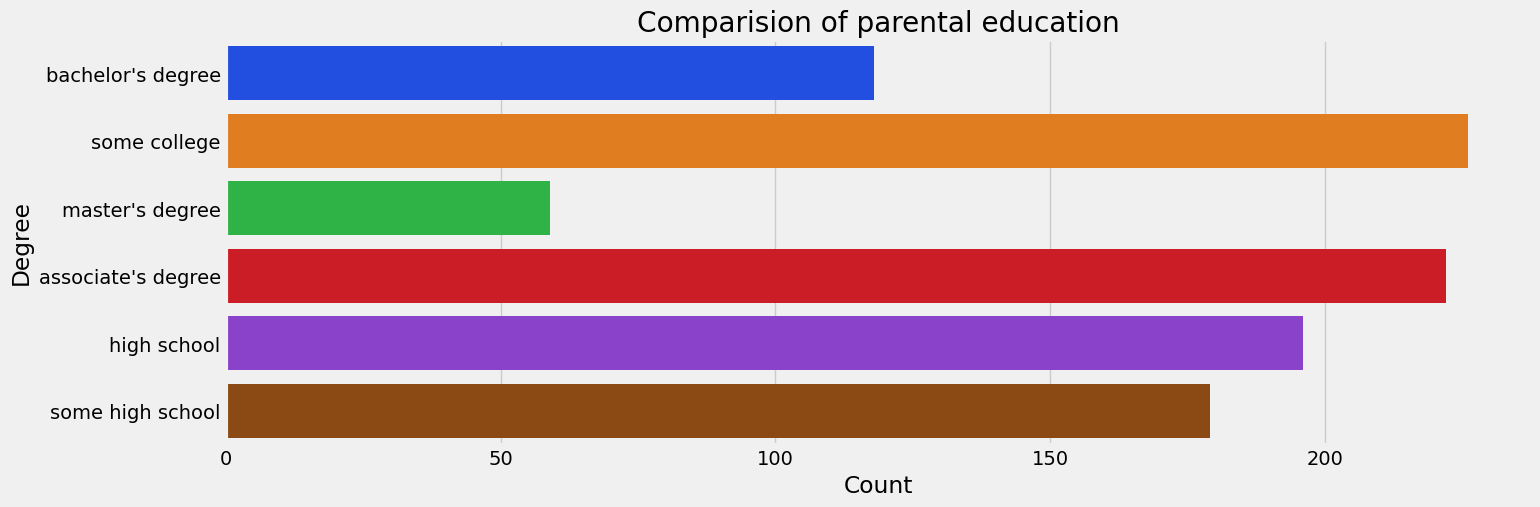

In [91]:
plt.figure(figsize=(15,5))
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette='bright')
plt.title('Comparision of parental education')
plt.xlabel('Count')
plt.ylabel('Degree')
plt.show()

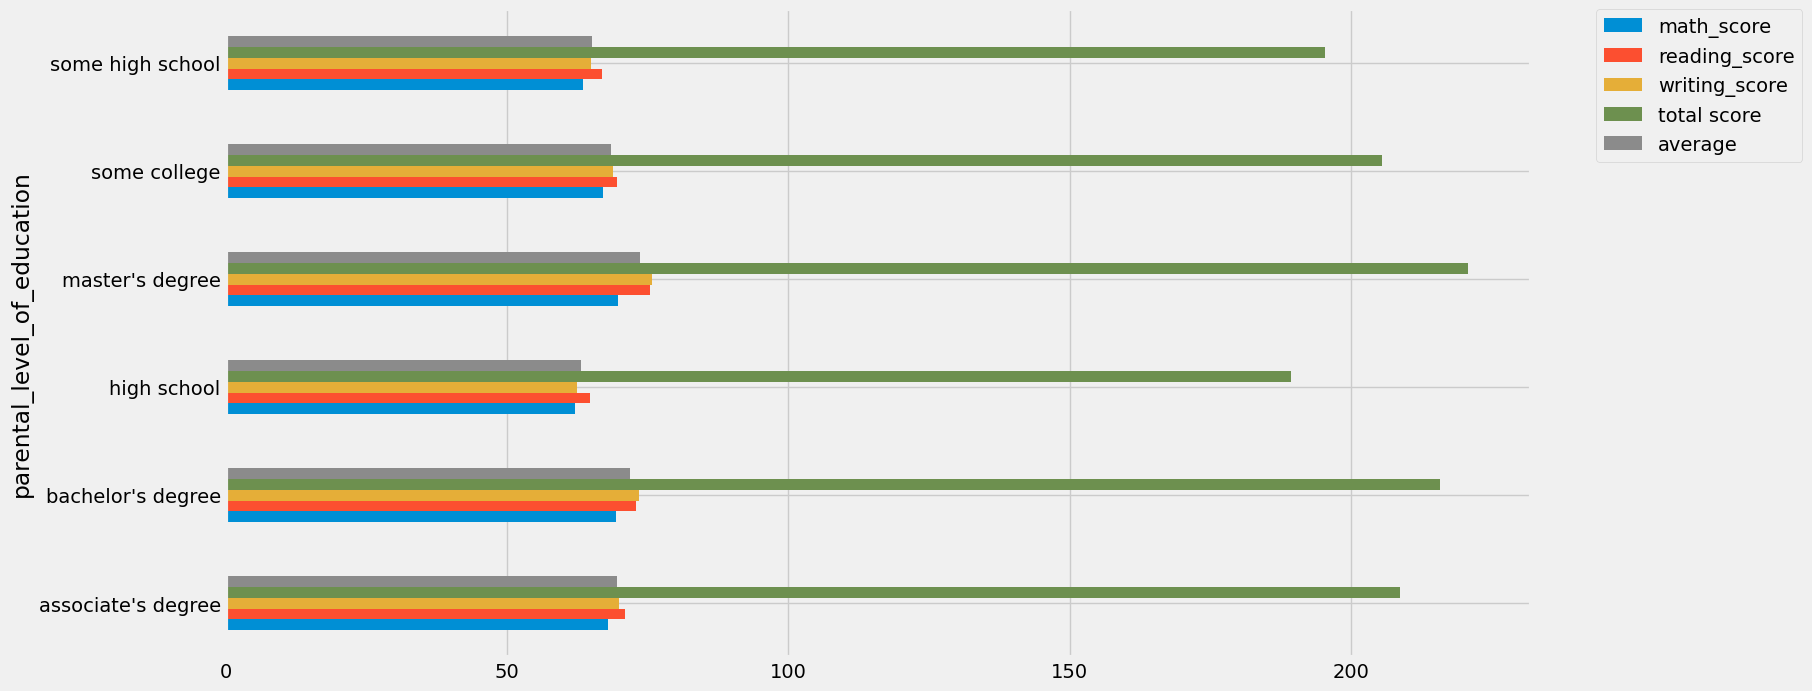

In [94]:
df.groupby('parental_level_of_education').mean(numeric_only=True).plot(kind='barh', figsize=(15,8))
plt.legend(bbox_to_anchor=(1.05,1), loc=2, borderaxespad=0)
plt.show()

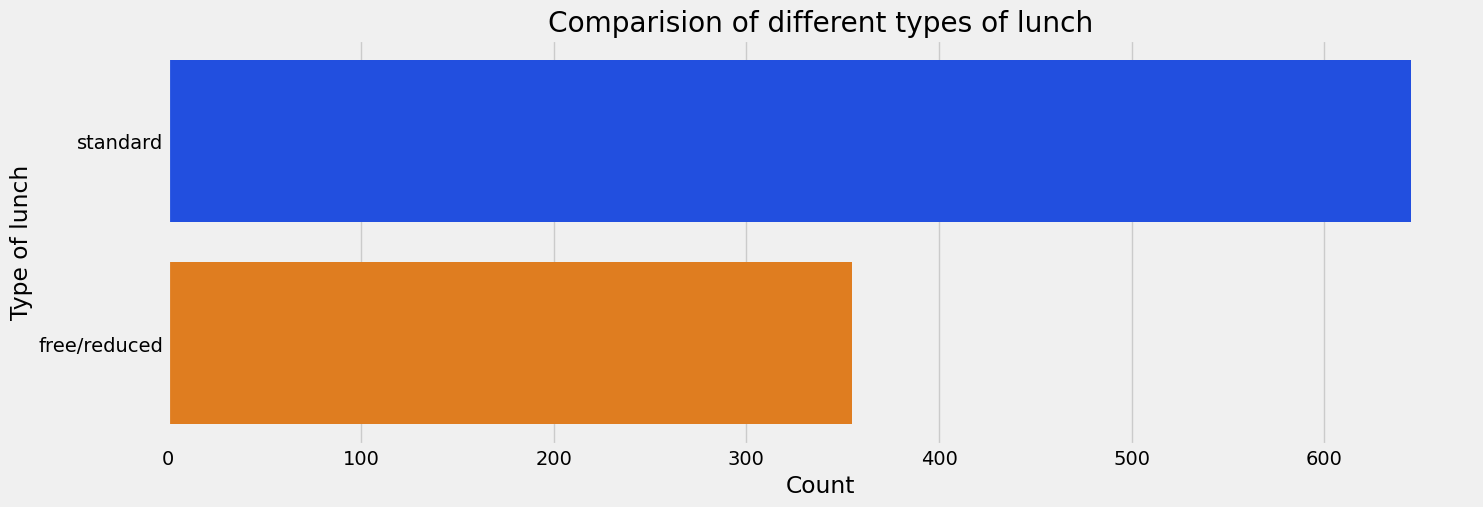

In [97]:
plt.figure(figsize=(15,5))
# plt.style.use('seaborn-talk')
sns.countplot(df['lunch'], palette='bright')
plt.title('Comparision of different types of lunch')
plt.xlabel('Count')
plt.ylabel('Type of lunch')
plt.show()

In [98]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


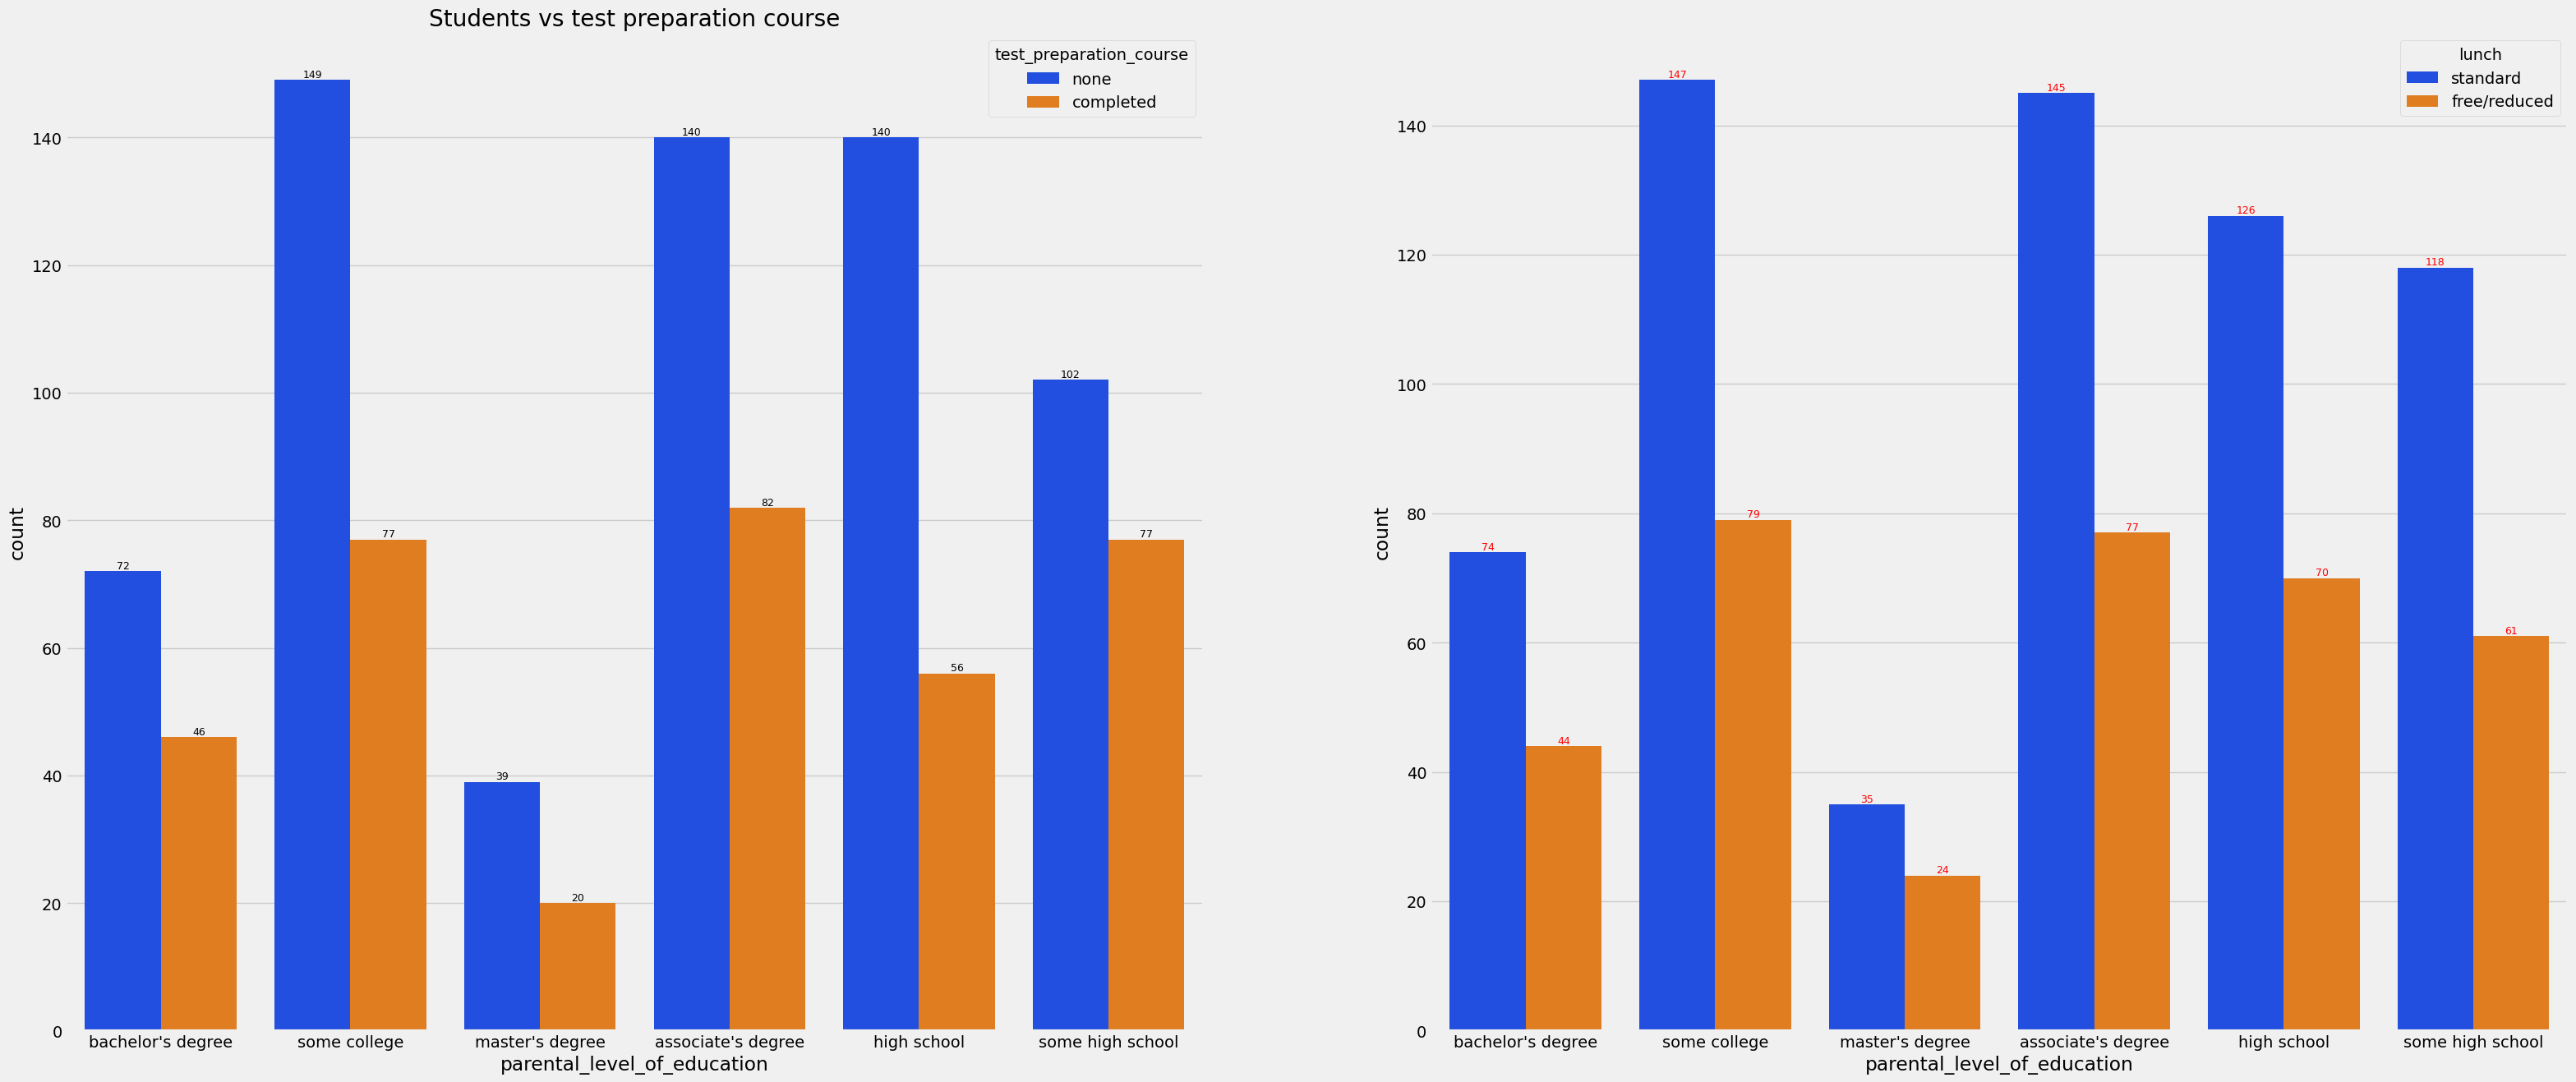

In [109]:
f,ax = plt.subplots(1,2,figsize=(35,15))
sns.countplot(x=df['parental_level_of_education'], data=df, palette='bright', hue='test_preparation_course', ax=ax[0])
ax[0].set_title('Students vs test preparation course')
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=9)
    
sns.countplot(x=df['parental_level_of_education'], data=df, palette='bright', hue='lunch', ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, color='red', size=9)

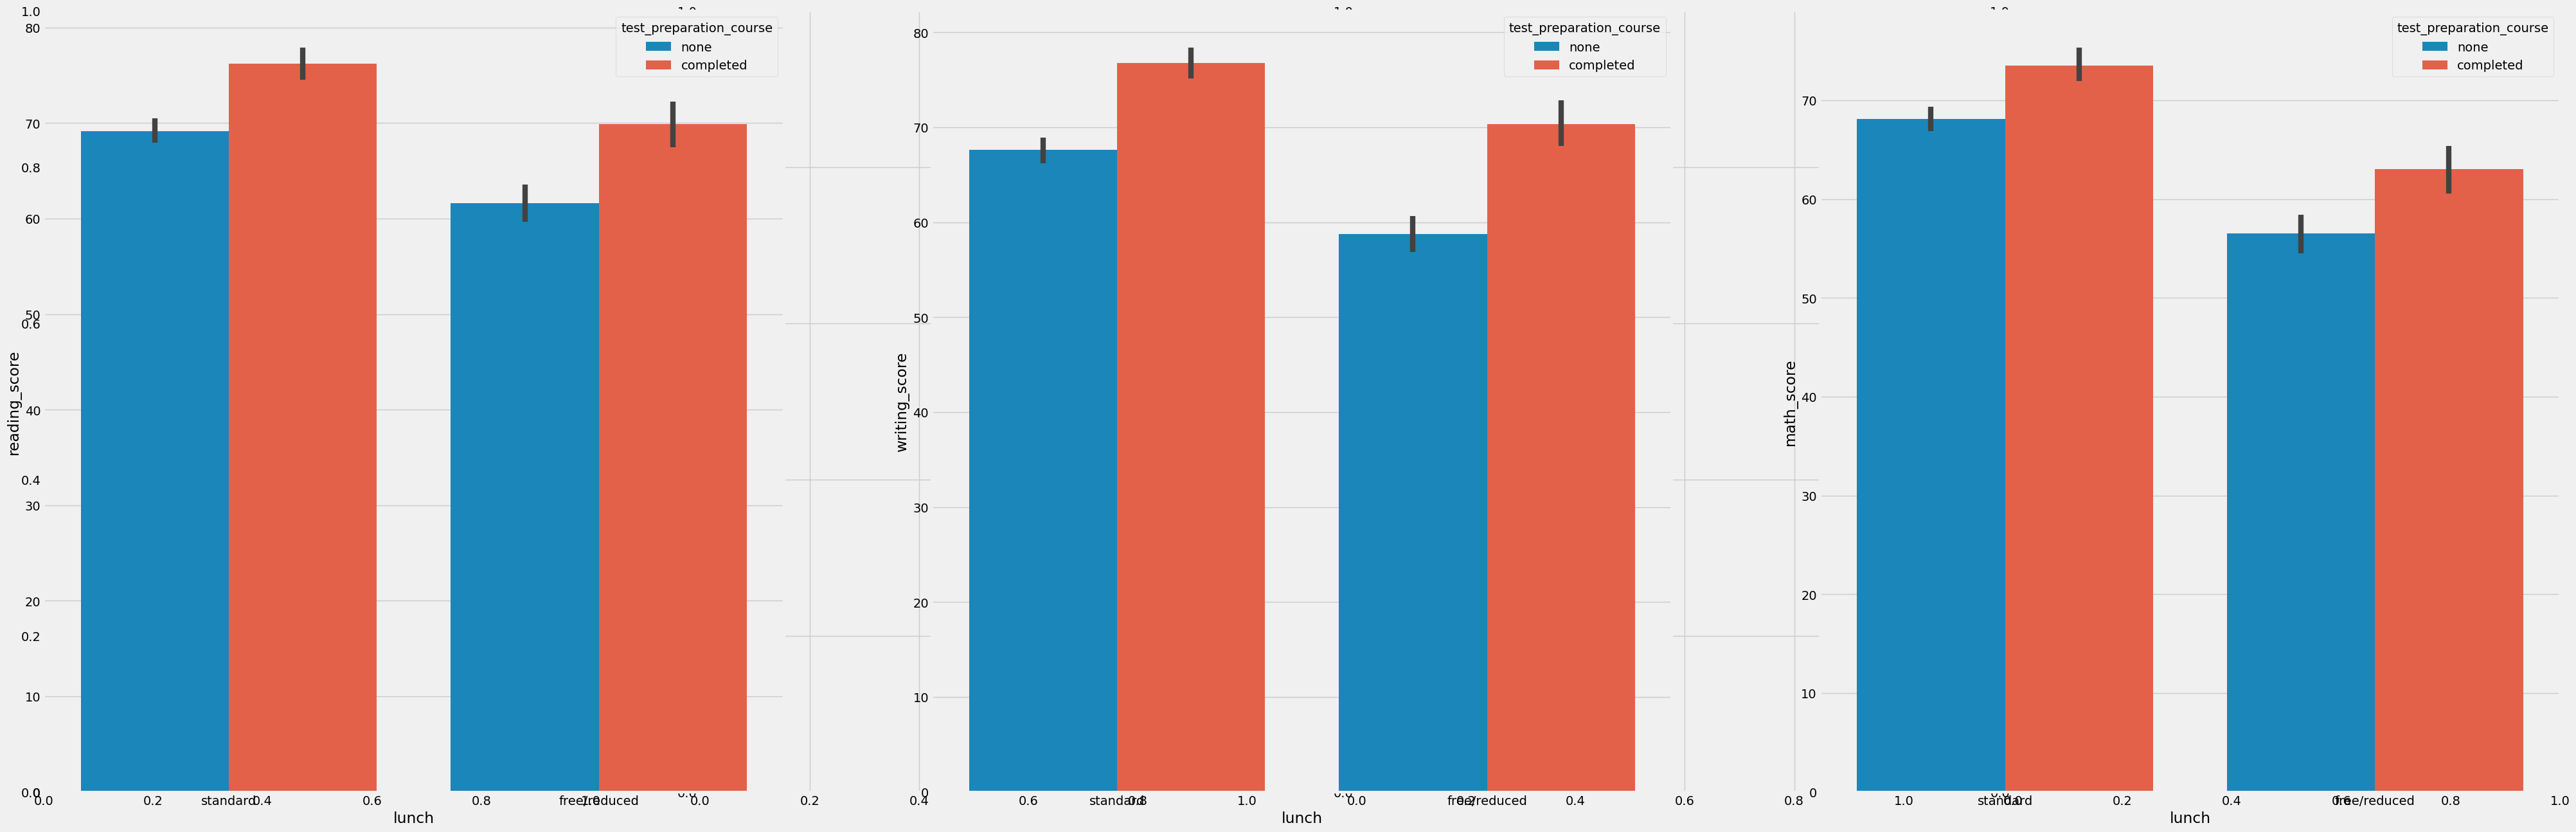

In [123]:
plt.subplots(1,4,figsize=(45,15))
plt.subplot(1,3,1)
sns.barplot(x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(1,3,2)
sns.barplot(x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])
plt.subplot(1,3,3)
sns.barplot(x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.show()

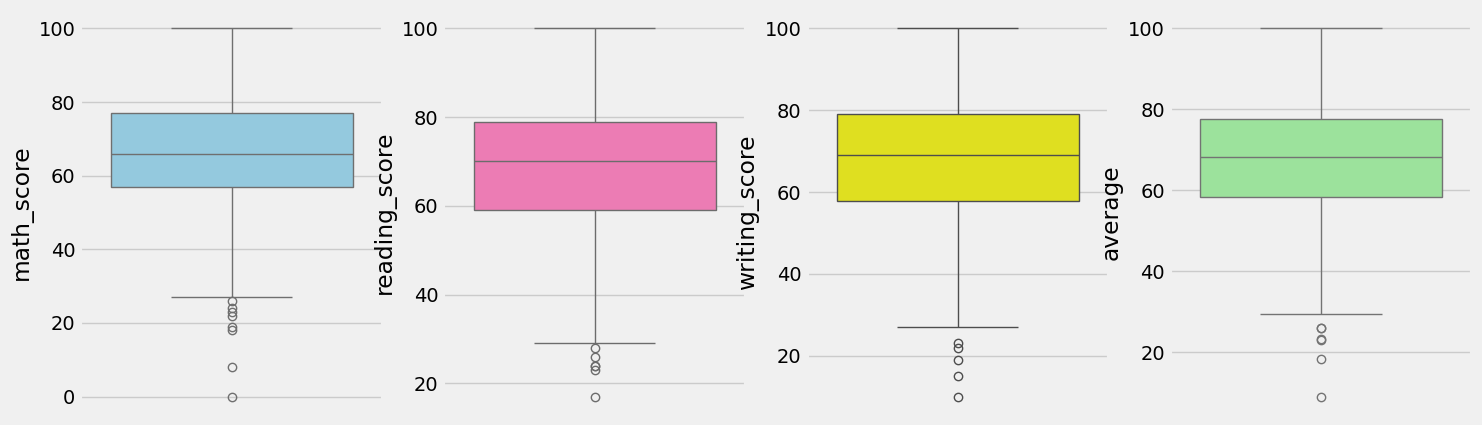

In [124]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

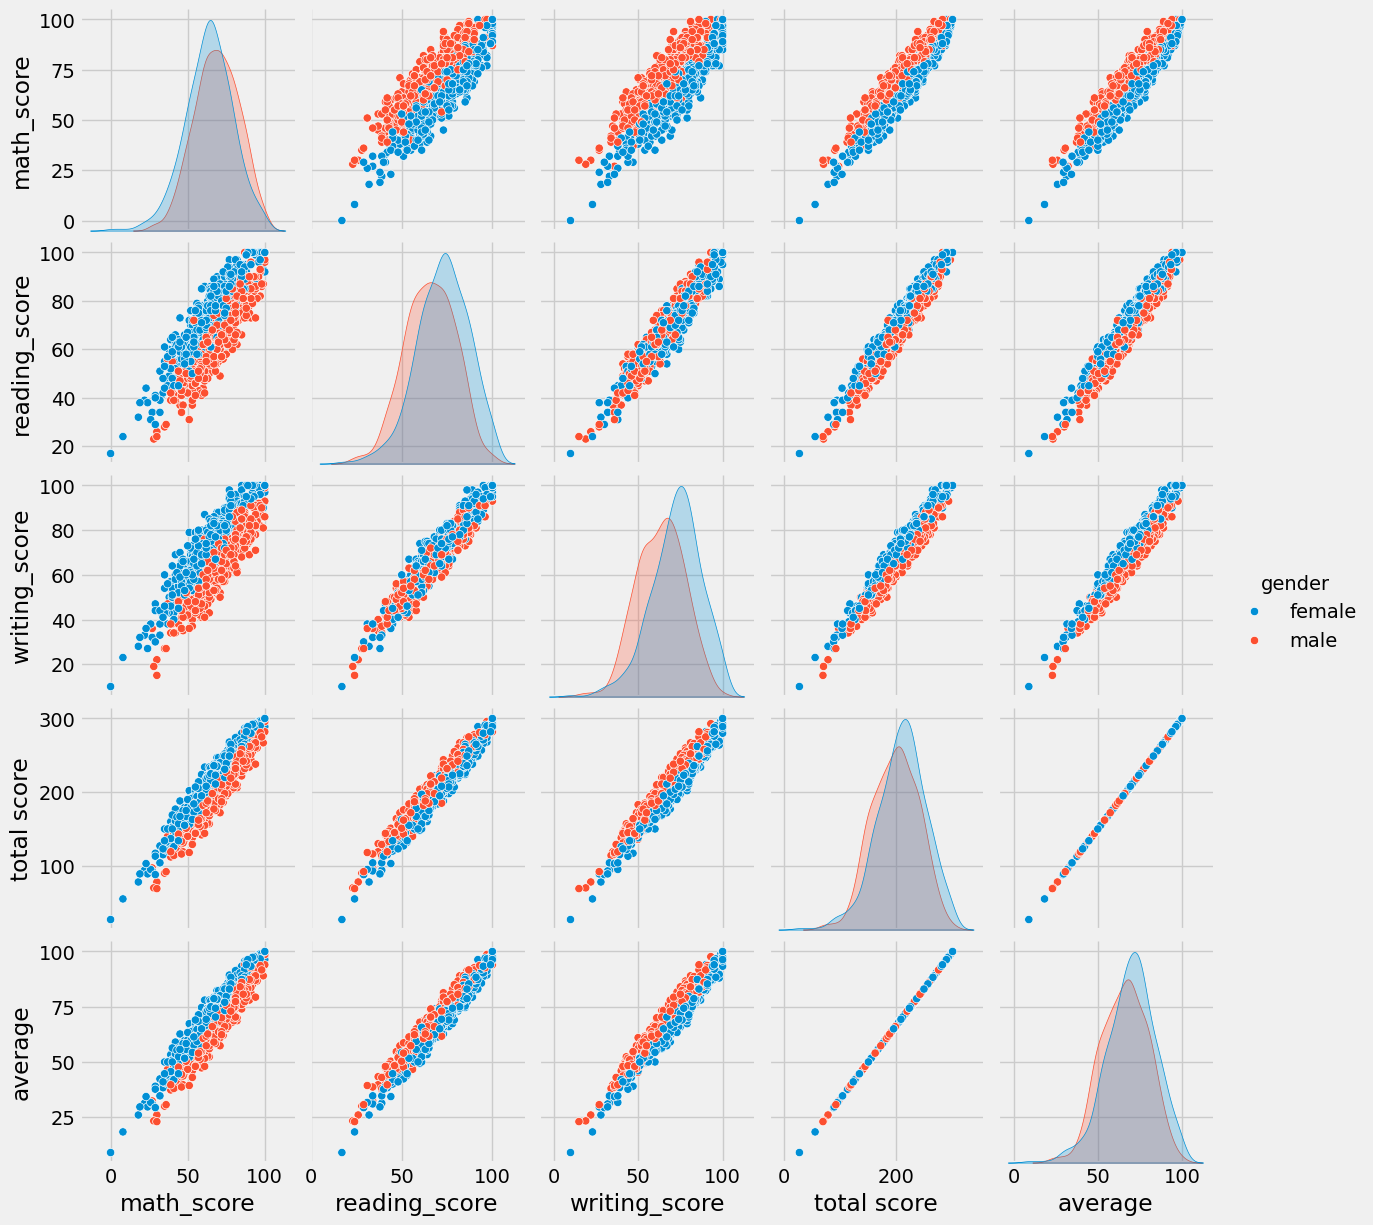

In [130]:
sns.pairplot(df,hue='gender')
plt.show()